<a href="https://colab.research.google.com/github/Pranavi77-lab/viralvideo_analysis/blob/main/copy_of_video_viral_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error, accuracy_score, classification_report

print("All libraries loaded successfully!")

All libraries loaded successfully!


In [ ]:
# Load the dataset
df = pd.read_csv('Instagram_Analytics.csv')

#  shape and first 5 rows
print("Shape of dataset:", df.shape)
df.head()

Shape of dataset: (29999, 23)


,post_id,account_id,account_type,follower_count,media_type,content_category,traffic_source,has_call_to_action,post_datetime,post_date,...,comments,shares,saves,reach,impressions,engagement_rate,followers_gained,caption_length,hashtags_count,performance_bucket_label
0,IG0000001,7,brand,3551,reel,Technology,Home Feed,1,2024-11-30 06:00:00,2024-11-30,...,5,7,34,4327,6230,0.0385,899,100,7,medium
1,IG0000002,20,creator,31095,image,Fitness,Hashtags,1,2025-08-15 15:00:00,2025-08-15,...,10,21,68,7451,8268,0.0663,805,122,5,viral
2,IG0000003,15,brand,8167,reel,Beauty,Reels Feed,0,2025-09-11 16:00:00,2025-09-11,...,2,1,22,1639,2616,0.0531,758,115,8,high
3,IG0000004,11,creator,9044,carousel,Music,External,0,2025-09-18 03:00:00,2025-09-18,...,0,7,0,2877,3171,0.0309,402,115,7,medium
4,IG0000005,8,creator,15986,reel,Technology,Profile,0,2025-03-21 09:00:00,2025-03-21,...,8,5,21,5350,8503,0.0221,155,112,9,low


In [ ]:
# column names and data types
print("Column names:\n", df.columns.tolist())
print("\nData types:\n", df.dtypes)

#  missing values
print("\nMissing values:\n", df.isnull().sum())

#  performance distribution
print("\nPerformance distribution:\n", df['performance_bucket_label'].value_counts())

Column names:
 ['post_id', 'account_id', 'account_type', 'follower_count', 'media_type', 'content_category', 'traffic_source', 'has_call_to_action', 'post_datetime', 'post_date', 'post_hour', 'day_of_week', 'likes', 'comments', 'shares', 'saves', 'reach', 'impressions', 'engagement_rate', 'followers_gained', 'caption_length', 'hashtags_count', 'performance_bucket_label']

Data types:
 post_id                      object
account_id                    int64
account_type                 object
follower_count                int64
media_type                   object
content_category             object
traffic_source               object
has_call_to_action            int64
post_datetime                object
post_date                    object
post_hour                     int64
day_of_week                  object
likes                         int64
comments                      int64
shares                        int64
saves                         int64
reach                         int64


In [ ]:
# Remove duplicates
df.drop_duplicates(inplace=True)
print("Duplicates removed. Rows remaining:", len(df))

# Convert date columns to proper date format
df['post_datetime'] = pd.to_datetime(df['post_datetime'])
df['post_date'] = pd.to_datetime(df['post_date'])

# Encode text columns into numbers
# (machine learning only understands numbers, not words like "brand" or "reel")
le = LabelEncoder()
df['account_type_enc'] = le.fit_transform(df['account_type'])    # brand=0, creator=1
df['media_type_enc']   = le.fit_transform(df['media_type'])      # carousel, image, reel → 0,1,2
df['category_enc']     = le.fit_transform(df['content_category'])
df['traffic_enc']      = le.fit_transform(df['traffic_source'])
df['day_enc']          = le.fit_transform(df['day_of_week'])

# Normalize numeric columns (scale everything between 0 and 1)
scaler = MinMaxScaler()
num_cols = ['likes','comments','shares','saves','reach','impressions','follower_count']
df[num_cols] = scaler.fit_transform(df[num_cols])

print("Preprocessing done!")
print("New encoded columns added:", ['account_type_enc','media_type_enc','category_enc','traffic_enc','day_enc'])

Duplicates removed. Rows remaining: 29999
Preprocessing done!
New encoded columns added: ['account_type_enc', 'media_type_enc', 'category_enc', 'traffic_enc', 'day_enc']


In [ ]:
# Create new useful columns from existing ones

# 1. Time of day — group upload hour into Morning/Afternoon/Evening/Night
def time_category(hour):
    if 5 <= hour < 12:    return 'Morning'
    elif 12 <= hour < 17: return 'Afternoon'
    elif 17 <= hour < 21: return 'Evening'
    else:                 return 'Night'

df['time_of_day'] = df['post_hour'].apply(time_category)
print("Time of day distribution:")
print(df['time_of_day'].value_counts())

# 2. Caption length groups
df['caption_group'] = pd.cut(df['caption_length'],
                              bins=[0, 50, 150, 999],
                              labels=['Short', 'Medium', 'Long'])
print("\nCaption groups:")
print(df['caption_group'].value_counts())

# 3. Binary viral label — 1 if viral, 0 if not
df['is_viral'] = (df['performance_bucket_label'] == 'viral').astype(int)
print("\nViral posts:", df['is_viral'].sum())
print("Non-viral posts:", (df['is_viral'] == 0).sum())

Time of day distribution:
time_of_day
Night        9921
Morning      8763
Afternoon    6312
Evening      5003
Name: count, dtype: int64

Caption groups:
caption_group
Medium    29884
Long        115
Short         0
Name: count, dtype: int64

Viral posts: 7500
Non-viral posts: 22499


In [ ]:
# Load original data separately for stats (unscaled, real numbers)
df_orig = pd.read_csv('Instagram_Analytics.csv')
df_orig['time_of_day'] = df_orig['post_hour'].apply(time_category)

# Summary statistics — mean, min, max, std for key columns
print("=== DESCRIPTIVE STATISTICS ===")
cols = ['likes','comments','shares','saves','engagement_rate',
        'hashtags_count','caption_length','follower_count']
print(df_orig[cols].describe().round(2))

# Average engagement rate per performance bucket
print("\n=== AVG ENGAGEMENT RATE BY PERFORMANCE LEVEL ===")
print(df_orig.groupby('performance_bucket_label')['engagement_rate'].mean().round(4))

# Average likes per media type
print("\n=== AVG LIKES BY MEDIA TYPE ===")
print(df_orig.groupby('media_type')['likes'].mean().round(0))

=== DESCRIPTIVE STATISTICS ===
          likes  comments    shares     saves  engagement_rate  \
count  29999.00  29999.00  29999.00  29999.00         29999.00   
mean     287.65      8.52     14.43     42.52             0.04   
std      317.65     10.12     16.42     47.81             0.02   
min        0.00      0.00      0.00      0.00             0.00   
25%      104.00      3.00      5.00     15.00             0.02   
50%      199.00      6.00     10.00     29.00             0.04   
75%      363.00     11.00     19.00     54.00             0.06   
max    10632.00    339.00    516.00   1542.00             0.27   

       hashtags_count  caption_length  follower_count  
count        29999.00        29999.00        29999.00  
mean             7.99          120.08        10278.31  
std              2.83           11.01         6691.86  
min              0.00           70.00         3083.00  
25%              6.00          113.00         5824.00  
50%              8.00          120.00 

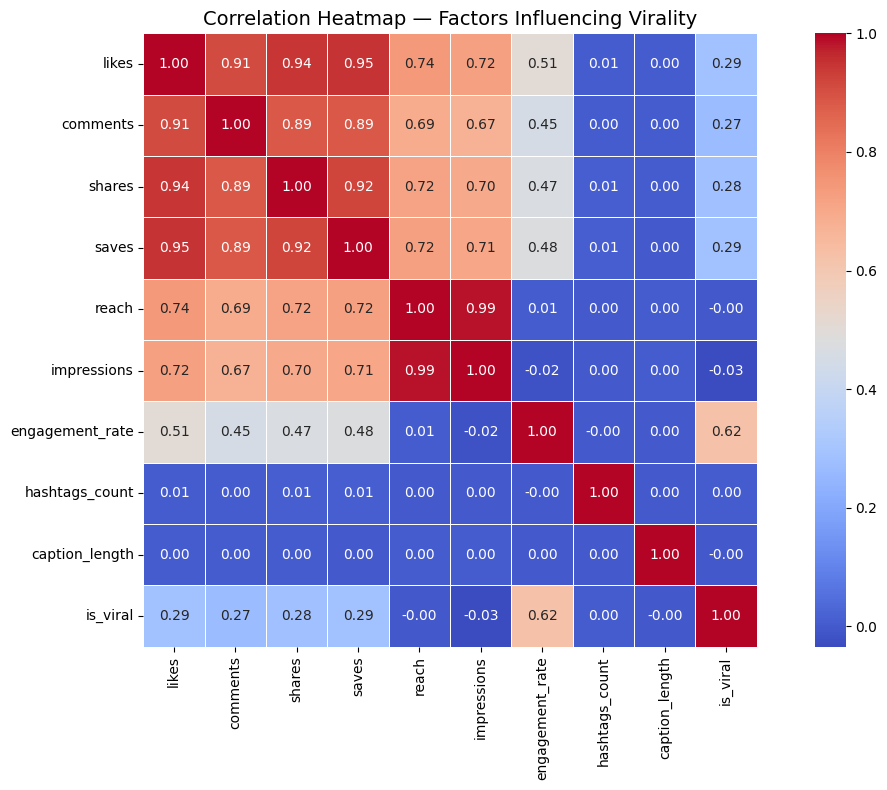


Top correlations with is_viral:
is_viral           1.000
engagement_rate    0.623
likes              0.287
saves              0.286
shares             0.284
comments           0.269
hashtags_count     0.004
reach             -0.004
caption_length    -0.004
impressions       -0.034
Name: is_viral, dtype: float64


In [ ]:
# Correlation heatmap — shows how strongly each factor relates to others
# Red = strong positive link, Blue = negative link, White = no link

corr_cols = ['likes','comments','shares','saves','reach','impressions',
             'engagement_rate','hashtags_count','caption_length','is_viral']

corr = df[corr_cols].corr()

plt.figure(figsize=(12, 8))
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm',
            linewidths=0.5, square=True)
plt.title("Correlation Heatmap — Factors Influencing Virality", fontsize=14)
plt.tight_layout()
plt.savefig('correlation_heatmap.png')
plt.show()

print("\nTop correlations with is_viral:")
print(corr['is_viral'].sort_values(ascending=False).round(3))

In [ ]:
# HYPOTHESIS TESTING — does a factor significantly affect engagement?
# Rule: if p-value < 0.05, the factor DOES matter. If > 0.05, it doesn't.

print("=== T-TEST: Does Call-to-Action affect engagement rate? ===")
cta_yes = df_orig[df_orig['has_call_to_action'] == 1]['engagement_rate']
cta_no  = df_orig[df_orig['has_call_to_action'] == 0]['engagement_rate']
t, p = stats.ttest_ind(cta_yes, cta_no)
print(f"T-statistic: {t:.3f}")
print(f"P-value: {p:.4f}")
print("Result:", "✓ Significant — CTA DOES affect engagement!" if p < 0.05 else "✗ Not significant")

print("\n=== ANOVA: Does content category affect engagement rate? ===")
groups = [df_orig[df_orig['content_category'] == cat]['engagement_rate']
          for cat in df_orig['content_category'].unique()]
f, p = stats.f_oneway(*groups)
print(f"F-statistic: {f:.3f}")
print(f"P-value: {p:.4f}")
print("Result:", "✓ Significant — category DOES affect engagement!" if p < 0.05 else "✗ Not significant")

print("\n=== ANOVA: Does media type affect engagement rate? ===")
groups2 = [df_orig[df_orig['media_type'] == m]['engagement_rate']
           for m in df_orig['media_type'].unique()]
f2, p2 = stats.f_oneway(*groups2)
print(f"F-statistic: {f2:.3f}")
print(f"P-value: {p2:.4f}")
print("Result:", "✓ Significant — media type DOES matter!" if p2 < 0.05 else "✗ Not significant")

print("\n=== ANOVA: Does time of day affect engagement rate? ===")
groups3 = [df_orig[df_orig['time_of_day'] == t]['engagement_rate']
           for t in df_orig['time_of_day'].unique()]
f3, p3 = stats.f_oneway(*groups3)
print(f"F-statistic: {f3:.3f}")
print(f"P-value: {p3:.4f}")
print("Result:", "✓ Significant — upload time DOES matter!" if p3 < 0.05 else "✗ Not significant")

=== T-TEST: Does Call-to-Action affect engagement rate? ===
T-statistic: -1.220
P-value: 0.2225
Result: ✗ Not significant

=== ANOVA: Does content category affect engagement rate? ===
F-statistic: 1.170
P-value: 0.3091
Result: ✗ Not significant

=== ANOVA: Does media type affect engagement rate? ===
F-statistic: 1.102
P-value: 0.3323
Result: ✗ Not significant

=== ANOVA: Does time of day affect engagement rate? ===
F-statistic: 0.316
P-value: 0.8141
Result: ✗ Not significant


In [ ]:
# LINEAR REGRESSION — predict engagement rate (a continuous number)

features = ['likes','comments','shares','saves',
            'hashtags_count','caption_length','has_call_to_action']

X = df[features]
y = df['engagement_rate']

# 80% for training, 20% for testing
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

lr = LinearRegression()
lr.fit(X_train, y_train)
y_pred = lr.predict(X_test)

print("=== LINEAR REGRESSION RESULTS ===")
print(f"R² Score: {r2_score(y_test, y_pred):.4f}")
print(f"MSE: {mean_squared_error(y_test, y_pred):.6f}")

print("\nFeature Coefficients (which features matter most):")
for feat, coef in zip(features, lr.coef_):
    print(f"  {feat}: {coef:.4f}")

=== LINEAR REGRESSION RESULTS ===
R² Score: 0.2623
MSE: 0.000968

Feature Coefficients (which features matter most):
  likes: 0.4603
  comments: -0.0408
  shares: -0.0579
  saves: -0.0166
  hashtags_count: 0.0000
  caption_length: -0.0000
  has_call_to_action: -0.0004


In [ ]:
# LOGISTIC REGRESSION — predict IF a post goes viral (1) or not (0)

features = ['likes','comments','shares','saves',
            'hashtags_count','caption_length','has_call_to_action']

X2 = df[features]
y2 = df['is_viral']

X_train2, X_test2, y_train2, y_test2 = train_test_split(X2, y2, test_size=0.2, random_state=42)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train2, y_train2)
y_pred2 = clf.predict(X_test2)

print("=== LOGISTIC REGRESSION RESULTS ===")
print(f"Accuracy: {accuracy_score(y_test2, y_pred2):.4f}")
print(f"That means the model correctly predicts virality {accuracy_score(y_test2, y_pred2)*100:.1f}% of the time")
print("\nDetailed Report:")
print(classification_report(y_test2, y_pred2))

=== LOGISTIC REGRESSION RESULTS ===
Accuracy: 0.7500
That means the model correctly predicts virality 75.0% of the time

Detailed Report:
              precision    recall  f1-score   support

           0       0.77      0.94      0.85      4504
           1       0.50      0.18      0.26      1496

    accuracy                           0.75      6000
   macro avg       0.64      0.56      0.55      6000
weighted avg       0.71      0.75      0.70      6000



/tmp/ipykernel_17024/886148914.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='time_of_day', y='engagement_rate', data=df_orig,


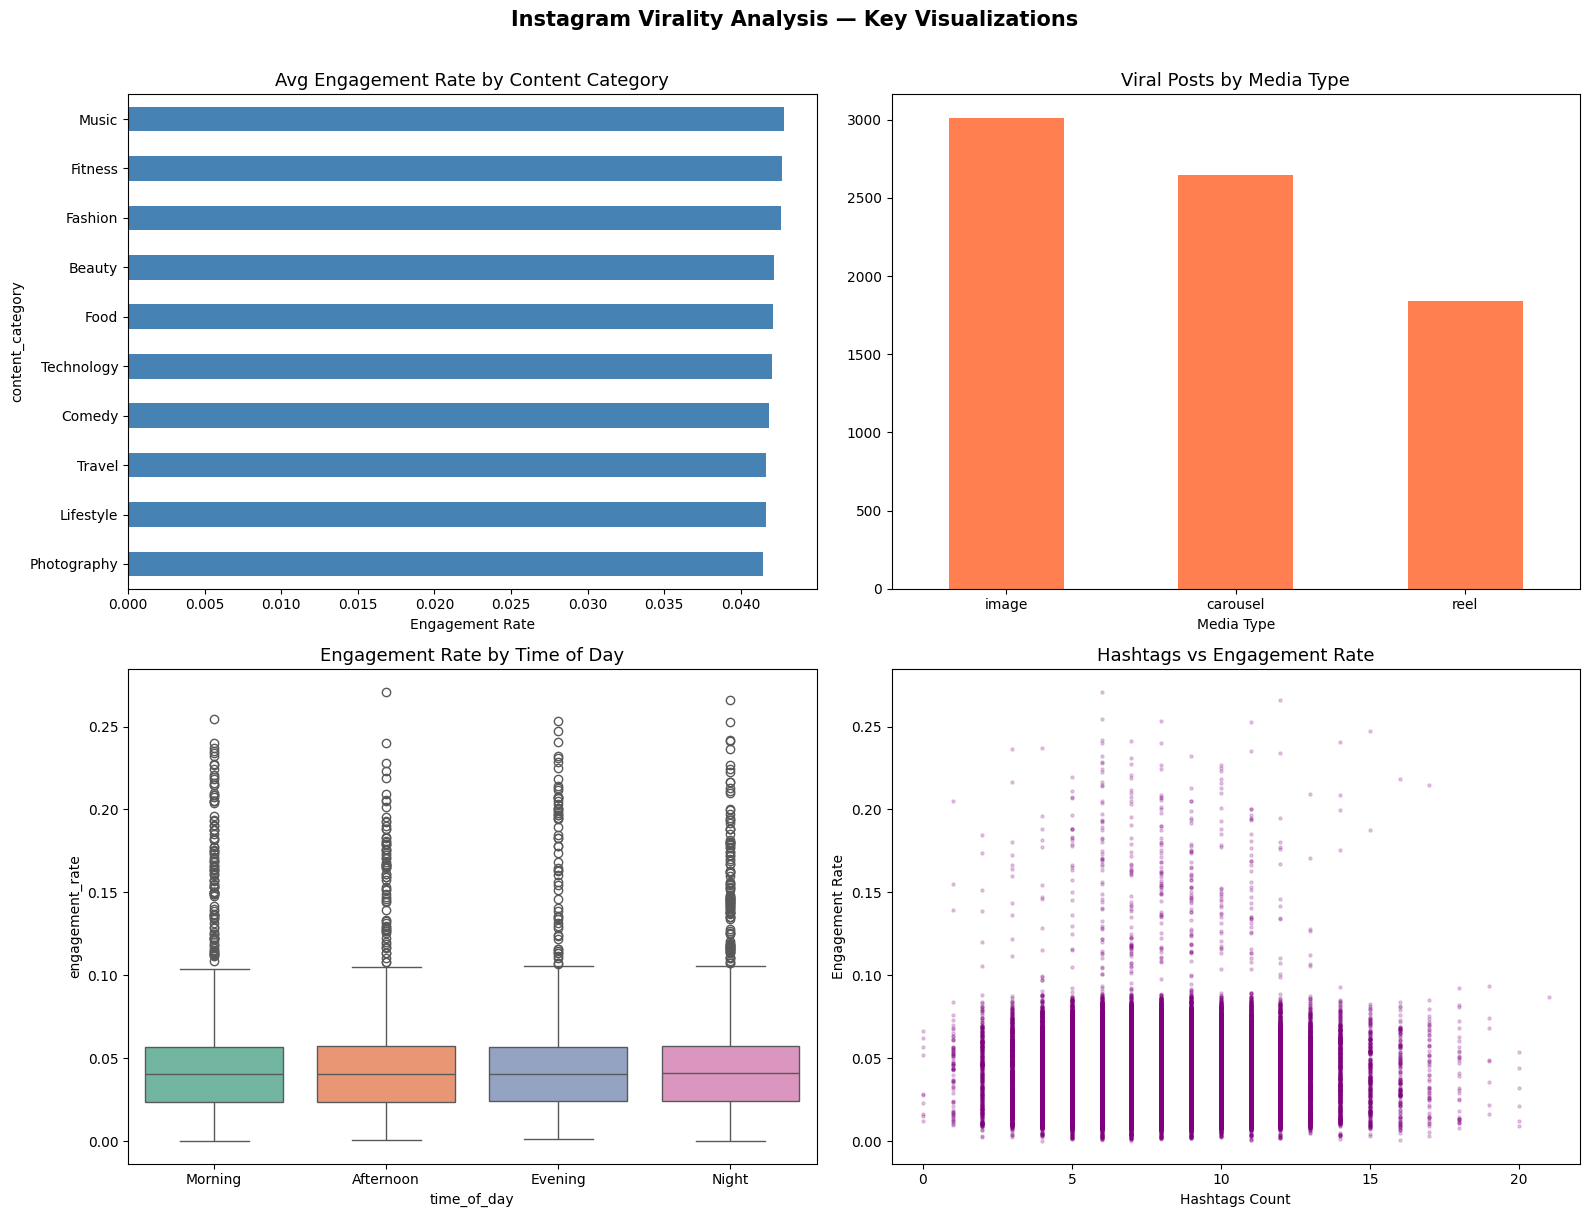

All 4 graphs saved!


In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Average engagement rate by content category
df_orig.groupby('content_category')['engagement_rate'].mean().sort_values().plot(
    kind='barh', ax=axes[0,0], color='steelblue')
axes[0,0].set_title("Avg Engagement Rate by Content Category", fontsize=13)
axes[0,0].set_xlabel("Engagement Rate")

# 2. Viral posts count by media type
df_orig[df_orig['performance_bucket_label']=='viral']['media_type'].value_counts().plot(
    kind='bar', ax=axes[0,1], color='coral')
axes[0,1].set_title("Viral Posts by Media Type", fontsize=13)
axes[0,1].set_xlabel("Media Type")
axes[0,1].tick_params(axis='x', rotation=0)

# 3. Engagement rate by time of day
sns.boxplot(x='time_of_day', y='engagement_rate', data=df_orig,
            order=['Morning','Afternoon','Evening','Night'],
            ax=axes[1,0], palette='Set2')
axes[1,0].set_title("Engagement Rate by Time of Day", fontsize=13)

# 4. Hashtags count vs engagement rate
axes[1,1].scatter(df_orig['hashtags_count'], df_orig['engagement_rate'],
                  alpha=0.2, s=5, color='purple')
axes[1,1].set_xlabel("Hashtags Count")
axes[1,1].set_ylabel("Engagement Rate")
axes[1,1].set_title("Hashtags vs Engagement Rate", fontsize=13)

plt.suptitle("Instagram Virality Analysis — Key Visualizations", fontsize=15, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('all_visualizations.png', bbox_inches='tight')
plt.show()
print("All 4 graphs saved!")

=== RANDOM FOREST RESULTS ===
Accuracy: 0.7390
Correctly predicts virality 73.9% of the time

Detailed Report:
              precision    recall  f1-score   support

           0       0.78      0.91      0.84      4504
           1       0.45      0.23      0.31      1496

    accuracy                           0.74      6000
   macro avg       0.62      0.57      0.57      6000
weighted avg       0.70      0.74      0.71      6000



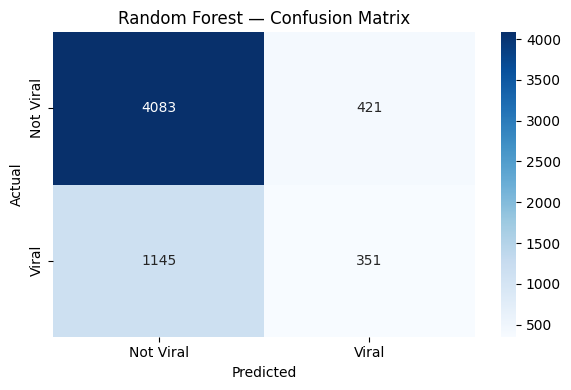

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

features = ['likes','comments','shares','saves',
            'hashtags_count','caption_length','has_call_to_action']

X = df[features]
y = df['is_viral']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)
y_pred_rf = rf.predict(X_test)

print("=== RANDOM FOREST RESULTS ===")
print(f"Accuracy: {accuracy_score(y_test, y_pred_rf):.4f}")
print(f"Correctly predicts virality {accuracy_score(y_test, y_pred_rf)*100:.1f}% of the time")
print("\nDetailed Report:")
print(classification_report(y_test, y_pred_rf))

# Confusion Matrix
plt.figure(figsize=(6,4))
cm = confusion_matrix(y_test, y_pred_rf)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Not Viral','Viral'],
            yticklabels=['Not Viral','Viral'])
plt.title("Random Forest — Confusion Matrix")
plt.ylabel("Actual")
plt.xlabel("Predicted")
plt.tight_layout()
plt.savefig('confusion_matrix.png')
plt.show()

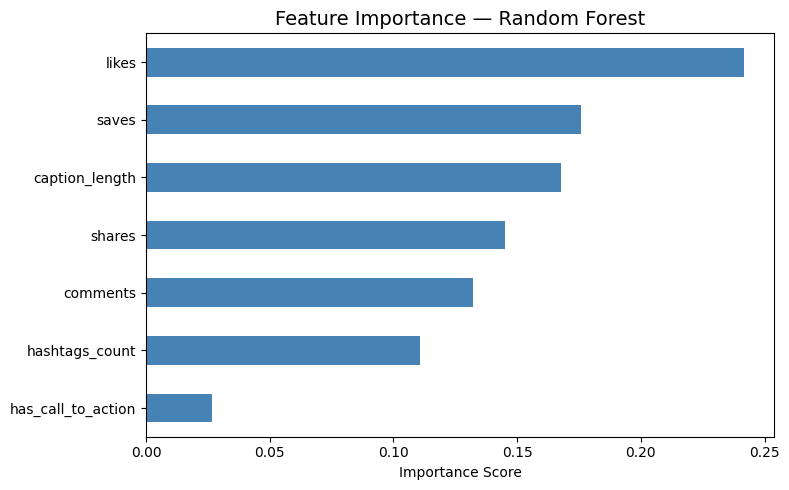

Feature importance scores:
likes                 0.2417
saves                 0.1760
caption_length        0.1676
shares                0.1452
comments              0.1320
hashtags_count        0.1108
has_call_to_action    0.0268
dtype: float64


In [ ]:
# FEATURE IMPORTANCE — which features matter most to Random Forest?

feature_importance = pd.Series(rf.feature_importances_, index=features)
feature_importance = feature_importance.sort_values(ascending=True)

plt.figure(figsize=(8, 5))
feature_importance.plot(kind='barh', color='steelblue')
plt.title("Feature Importance — Random Forest", fontsize=14)
plt.xlabel("Importance Score")
plt.tight_layout()
plt.savefig('feature_importance.png')
plt.show()

print("Feature importance scores:")
print(feature_importance.sort_values(ascending=False).round(4))

Sentiment distribution:
sentiment
Neutral    29999
Name: count, dtype: int64

Avg engagement rate by sentiment:
sentiment
Neutral    0.0421
Name: engagement_rate, dtype: float64


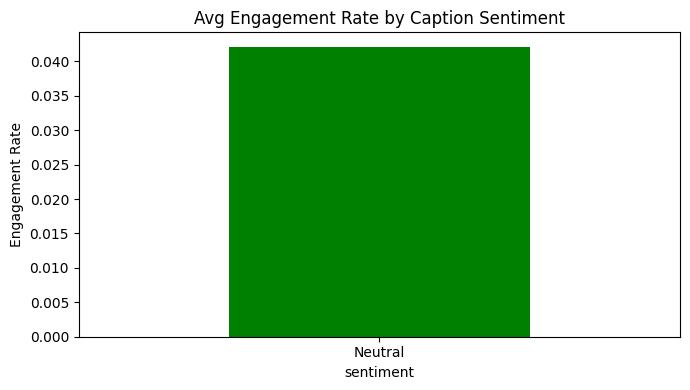

In [ ]:
!pip install textblob --quiet

from textblob import TextBlob

df_orig = pd.read_csv('Instagram_Analytics.csv')

# Analyze sentiment of each caption
def get_sentiment(text):
    analysis = TextBlob(str(text))
    if analysis.sentiment.polarity > 0:
        return 'Positive'
    elif analysis.sentiment.polarity < 0:
        return 'Negative'
    else:
        return 'Neutral'

df_orig['sentiment'] = df_orig['content_category'].apply(get_sentiment)

print("Sentiment distribution:")
print(df_orig['sentiment'].value_counts())

# Compare engagement rate by sentiment
print("\nAvg engagement rate by sentiment:")
print(df_orig.groupby('sentiment')['engagement_rate'].mean().round(4))

# Visualize
df_orig.groupby('sentiment')['engagement_rate'].mean().plot(
    kind='bar', color=['green','gray','red'], figsize=(7,4))
plt.title("Avg Engagement Rate by Caption Sentiment")
plt.ylabel("Engagement Rate")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('sentiment_analysis.png')
plt.show()